In [23]:
from tensorflow.keras import layers, models, utils
from sqlite3 import connect
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

db = connect('../StocksPlatform/app.db')

In [27]:
prices = pd.read_sql('SELECT AssetId, Timestamp, Price, Volume FROM AssetDailyHistory', db)
assets = pd.read_sql('SELECT Id, Symbol, Country FROM Assets', db)
prices = prices.merge(assets, left_on='AssetId', right_on='Id', how='left').drop(columns=['Id'])
prices

,AssetId,Timestamp,Price,Volume,Symbol,Country
0,2C586544-7C13-625C-AB97-C0DE16AECF5D,2021-03-15 00:00:00,235.979995727539,88006800,TSLA,United States
1,2C586544-7C13-625C-AB97-C0DE16AECF5D,2021-03-16 00:00:00,225.626663208008,96587100,TSLA,United States
2,2C586544-7C13-625C-AB97-C0DE16AECF5D,2021-03-17 00:00:00,233.936660766602,121117500,TSLA,United States
3,2C586544-7C13-625C-AB97-C0DE16AECF5D,2021-03-18 00:00:00,217.720001220703,99674400,TSLA,United States
4,2C586544-7C13-625C-AB97-C0DE16AECF5D,2021-03-19 00:00:00,218.289993286133,128682000,TSLA,United States
...,...,...,...,...,...,...
531437,FE3734E7-9384-E75E-A60E-33931F996473,2026-03-16 00:00:00,316.0,84227,SNI,Norway
531438,FE3734E7-9384-E75E-A60E-33931F996473,2026-03-17 00:00:00,320.5,55846,SNI,Norway
531439,FE3734E7-9384-E75E-A60E-33931F996473,2026-03-18 00:00:00,333.0,40959,SNI,Norway
531440,FE3734E7-9384-E75E-A60E-33931F996473,2026-03-19 00:00:00,329.0,48530,SNI,Norway


In [ ]:
# prices[prices["Country"]=="United States"]["Symbol"].value_counts()

GOOGL    2515
AMZN     2515
NVDA     2515
MSFT     2515
TSM      2515
AAPL     1261
TSLA     1256
Name: Symbol, dtype: int64

  0%|          | 0/5 [00:00<?, ?it/s]

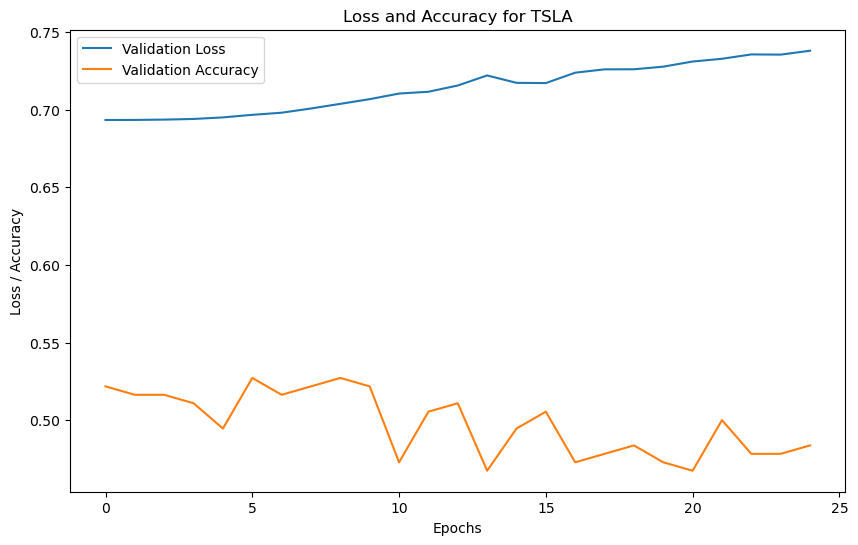

 20%|██        | 1/5 [00:05<00:20,  5.23s/it]


KeyboardInterrupt: 

In [ ]:
symbols = prices["Symbol"].unique()

# Train a model to predict the next day's price based on the previous 30 days of prices, for each stock symbol separately.
window_size = 30
models_by_symbol = {}
losses_by_symbol = {}
n_models_to_train = 3
for symbol in tqdm(symbols):
    symbol_prices = prices[prices["Symbol"] == symbol].sort_values("Timestamp")
    _prices = np.array(symbol_prices["Price"].values).astype(np.float32)
    logreturns = np.diff(np.log(_prices))
    if len(symbol_prices) < window_size + 1:
        continue

    X = []
    y = []
    for i in range(len(symbol_prices) - window_size - 1):
        X.append(logreturns[i:i+window_size])
        y.append(logreturns[i+window_size] > 0)  # Binary classification: will the price go up or down?

    X = np.array(X)
    y = utils.to_categorical(y, num_classes=2)

    models_by_symbol[symbol] = []
    losses_by_symbol[symbol] = []
    for _ in range(n_models_to_train):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
        # Shuffle the training data
        X_train, y_train = shuffle(X_train, y_train, random_state=42)

        model = models.Sequential([
            layers.Input(shape=(window_size,)),
            layers.Dense(32, activation='leaky_relu'),
            layers.Dense(64, activation='leaky_relu'),
            layers.Dense(2, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0, validation_data=(X_test, y_test))
        models_by_symbol[symbol].append(model)


        # Calculate the loss
        loss = model.evaluate(X_test, y_test, verbose=0)
        losses_by_symbol[symbol].append(loss)


In [32]:
losses_by_symbol

{'TSLA': [0.7148892879486084, 0.47154471278190613],
 'TEQ': [0.6768771409988403, 0.6341463327407837],
 'EQNR': [0.6994348764419556, 0.5967742204666138],
 'AAPL': [0.7025697231292725, 0.5121951103210449],
 'TPZ': [0.7314926385879517, 0.45864662528038025]}